In [2]:
from cellpose import io, models, train
import numpy as np
import os

In [27]:
TRAIN_PATH = '/scr/data/annotated_mn_datasets/train/images'
mn_gt_files = sorted(os.listdir(TRAIN_PATH.replace('images', 'mn_masks')))
nuc_gt_files = sorted(os.listdir(TRAIN_PATH.replace('images', 'nuclei_masks')))
# imgs = [io.imread(os.path.join(TRAIN_PATH, f)) for f in filelist]
mn_gts = [io.imread(os.path.join(TRAIN_PATH.replace('images', 'mn_masks'), f)) for f in mn_gt_files]
nuc_gts = [io.imread(os.path.join(TRAIN_PATH.replace('images', 'nuclei_masks'), f)) for f in nuc_gt_files]


In [31]:
files = os.listdir(TRAIN_PATH)
filelist = sorted([file for file in files if not file.startswith('.')])
filelist

['2022-03-18_RPE1-3.tif',
 '2022-03-18_RPE1-4.tif',
 '2022-03-18_RPE1-5.tif',
 '2022-04-14_RPE1-2.tif',
 '2022-04-14_RPE1-2198.tif',
 '2022-04-14_RPE1-5.tif',
 '2022-05-25_RPE1-1.tif',
 '2022-05-25_RPE1-2.tif',
 '2022-05-25_RPE1-3.tif',
 '2022-05-26_RPE1-1.tif',
 '2022-05-26_RPE1-2.tif',
 '2022-05-27_RPE1-1.tif',
 '2022-05-27_RPE1-2197.tif',
 '2022-05-27_RPE1-3.tif',
 '2022-10-14_U2OS-1.tif',
 '2022-10-14_U2OS-10.tif',
 '2022-10-14_U2OS-3.tif',
 '2022-10-14_U2OS-5.tif',
 '2022-10-14_U2OS-7.tif',
 '2022-10-14_U2OS-9.tif',
 '2023-05-31_misc-1.tif',
 '2023-05-31_misc-10.tif',
 '2023-05-31_misc-11.tif',
 '2023-05-31_misc-2.tif',
 '2023-05-31_misc-3.tif',
 '2023-05-31_misc-5.tif',
 '2023-05-31_misc-6.tif',
 '2023-05-31_misc-7.tif',
 '2023-05-31_misc-8.tif',
 '2023-05-31_misc-9.tif',
 '20X_c0-DAPI_A1_Tile-10.tif',
 '20X_c0-DAPI_A1_Tile-110.tif',
 '20X_c0-DAPI_A1_Tile-170.tif',
 '20X_c0-DAPI_A1_Tile-190.tif',
 '20X_c0-DAPI_A1_Tile-30.tif',
 '20X_c0-DAPI_A1_Tile-70.tif',
 '20X_c0-DAPI_A1_Tile-

In [29]:
mn_gt_files

['2022-03-18_RPE1-3.png',
 '2022-03-18_RPE1-4.png',
 '2022-03-18_RPE1-5.png',
 '2022-04-14_RPE1-2.png',
 '2022-04-14_RPE1-2198.png',
 '2022-04-14_RPE1-5.png',
 '2022-05-25_RPE1-1.png',
 '2022-05-25_RPE1-2.png',
 '2022-05-25_RPE1-3.png',
 '2022-05-26_RPE1-1.png',
 '2022-05-26_RPE1-2.png',
 '2022-05-27_RPE1-1.png',
 '2022-05-27_RPE1-2197.png',
 '2022-05-27_RPE1-3.png',
 '2022-10-14_U2OS-1.png',
 '2022-10-14_U2OS-10.png',
 '2022-10-14_U2OS-3.png',
 '2022-10-14_U2OS-5.png',
 '2022-10-14_U2OS-7.png',
 '2022-10-14_U2OS-9.png',
 '2023-05-31_misc-1.png',
 '2023-05-31_misc-10.png',
 '2023-05-31_misc-11.png',
 '2023-05-31_misc-2.png',
 '2023-05-31_misc-3.png',
 '2023-05-31_misc-5.png',
 '2023-05-31_misc-6.png',
 '2023-05-31_misc-7.png',
 '2023-05-31_misc-8.png',
 '2023-05-31_misc-9.png',
 '20X_c0-DAPI_A1_Tile-10.png',
 '20X_c0-DAPI_A1_Tile-110.png',
 '20X_c0-DAPI_A1_Tile-170.png',
 '20X_c0-DAPI_A1_Tile-190.png',
 '20X_c0-DAPI_A1_Tile-30.png',
 '20X_c0-DAPI_A1_Tile-70.png',
 '20X_c0-DAPI_A1_Tile-

In [30]:
nuc_gt_files

['2022-03-18_RPE1-3.tif',
 '2022-03-18_RPE1-4.tif',
 '2022-03-18_RPE1-5.tif',
 '2022-04-14_RPE1-2.tif',
 '2022-04-14_RPE1-2198.tif',
 '2022-04-14_RPE1-5.tif',
 '2022-05-25_RPE1-1.tif',
 '2022-05-25_RPE1-2.tif',
 '2022-05-25_RPE1-3.tif',
 '2022-05-26_RPE1-1.tif',
 '2022-05-26_RPE1-2.tif',
 '2022-05-27_RPE1-1.tif',
 '2022-05-27_RPE1-2197.tif',
 '2022-05-27_RPE1-3.tif',
 '2022-10-14_U2OS-1.tif',
 '2022-10-14_U2OS-10.tif',
 '2022-10-14_U2OS-3.tif',
 '2022-10-14_U2OS-5.tif',
 '2022-10-14_U2OS-7.tif',
 '2022-10-14_U2OS-9.tif',
 '2023-05-31_misc-1.tif',
 '2023-05-31_misc-10.tif',
 '2023-05-31_misc-11.tif',
 '2023-05-31_misc-2.tif',
 '2023-05-31_misc-3.tif',
 '2023-05-31_misc-5.tif',
 '2023-05-31_misc-6.tif',
 '2023-05-31_misc-7.tif',
 '2023-05-31_misc-8.tif',
 '2023-05-31_misc-9.tif',
 '20X_c0-DAPI_A1_Tile-10.tif',
 '20X_c0-DAPI_A1_Tile-110.tif',
 '20X_c0-DAPI_A1_Tile-170.tif',
 '20X_c0-DAPI_A1_Tile-190.tif',
 '20X_c0-DAPI_A1_Tile-30.tif',
 '20X_c0-DAPI_A1_Tile-70.tif',
 '20X_c0-DAPI_A1_Tile-

In [ ]:
for m, n in zip(mn_gts, nuc_gts)

In [32]:
def merge_instances(mn, nuc):
    return mn + np.where(nuc > 0, nuc + mn.max(), 0)

combined = [merge_instances(m, n) for m, n in zip(mn_gts, nuc_gts)]

In [23]:
combined = merge_instances(mn_gts[0], nuc_gts[0])
combined

array([[ 0,  0,  0, ..., 13, 13, 13],
       [ 0,  0,  0, ..., 13, 13, 13],
       [ 0,  0,  0, ..., 13, 13, 13],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], shape=(520, 696), dtype=int32)

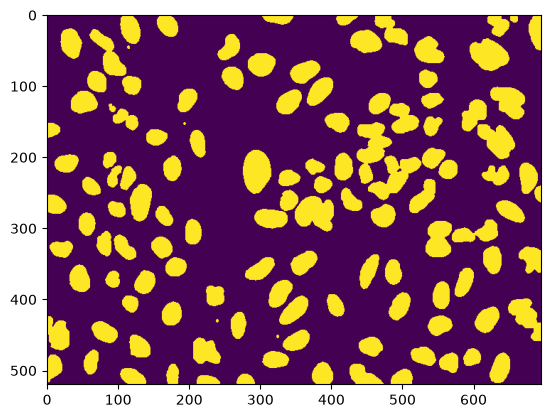

In [24]:
import matplotlib.pyplot as plt


plt.imshow(combined > 0)

# Inspect MicroSAM Data

In [1]:
import os
import numpy
import skimage
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

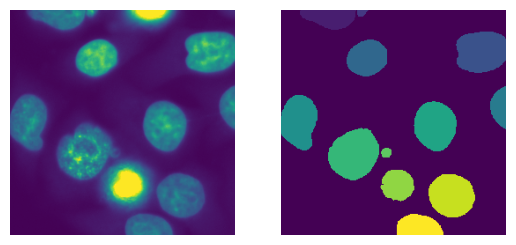

In [9]:
idx = 46

img_path = f'/scr/yren/microsam_data/train/20X_c0-DAPI_A1_Tile-90.crop{idx}.tif'
mask_path = f'/scr/yren/microsam_data/train/20X_c0-DAPI_A1_Tile-90.crop{idx}.png'

im = skimage.io.imread(img_path)
mask = skimage.io.imread(mask_path)

fig, ax = plt.subplots(1, 2)
ax[0].imshow(im)
ax[0].axis('off')

ax[1].imshow(mask)
ax[1].axis('off')